# 🧪 Biharmonic Inpainting & One-vs-All Classification Demo

This notebook demonstrates the core mathematical mechanics of **biharmonic inpainting** and the **One-vs-All (OvA)** classification strategy on a **10 × 10 play grid**.

---

### Key Concepts Covered:

1. **What does the Biharmonic Inpaint Operator actually do?**
   - The biharmonic equation $\nabla^4 u = \nabla^2(\nabla^2 u) = 0$ enforces minimum Laplacian curvature across unconstrained grid cells.
   - It outputs a **continuous floating-point field** (typically scaled between $0.0$ and $1.0$).
2. **Example 1: Single Data Point**
   - We place **1 data point** (Sand = 1.0) at the bottom-right corner `(x=9, y=0)` and inpaint the rest of the 99 empty cells.
   - Panel 1: Sparse Gridded Data.
   - Panel 2: Actual continuous inpaint values (showing every cell between 0 and 1).
   - Panel 3: Rounded values (thresholded to 0 or 1).
3. **Example 2: Two Data Points (Single Binary Dimension)**
   - We add a second data point at the top-left corner `(x=0, y=9)` with value $0.0$ (absence of Sand), opposite the bottom-right point with value $1.0$ (presence of Sand).
   - Panel 1: Sparse Gridded Data (two anchor points).
   - Panel 2: Continuous Biharmonic Field (smooth gradient from 0.0 to 1.0 across the grid).
   - Panel 3: Rounded values (clean diagonal decision boundary between 0 and 1).
4. **Example 3: Multi-class Geological Modeling with One-vs-All**
   - Two actual geological units: **Clay (Unit 2, green)** at top-left and **Sand (Unit 5, yellow)** at bottom-right.
   - Decomposing into binary problems:
     - Biharmonic function for Clay: $P(\text{Clay})$
     - Biharmonic function for Sand: $P(\text{Sand})$
   - Combining the two biharmonic probability functions via $\text{argmax}$ to yield the final classified geological model.
   - Uncertainty mapping ($\%$) revealing highest ambiguity (50%) along the decision boundary.
5. **Why One-vs-All is Essential (Failure of Direct Inpainting)**
   - Demonstrating why direct interpolation of integer unit codes (e.g., 2 and 5) produces phantom intermediate lithologies (3=Silt, 4=Nothing) that never existed in the borehole observations!


In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, Normalize
from skimage.restoration import inpaint_biharmonic

# -----------------------------------------------------------------------------
# Path Setup: Add gridder and local submodules
# -----------------------------------------------------------------------------
REPO_ROOT = os.path.abspath(os.path.dirname(''))
for sub in ['gridder', os.path.join('geo_vtk', 'src')]:
    p = os.path.join(REPO_ROOT, sub)
    if p not in sys.path:
        sys.path.insert(0, p)

from gridder import Geo_Gridder

print(f"Repo root: {REPO_ROOT}")
print("Modules imported successfully.")


Repo root: e:\karaouli\Projects\2025_ml_inpaint\github\Geology
Modules imported successfully.


In [2]:
# -----------------------------------------------------------------------------
# Geological Unit Codes and Official Colour Palette
# -----------------------------------------------------------------------------
UNIT_NAMES  = {0: 'anthropogenic', 2: 'clay', 5: 'sand', 8: 'gravel'}
UNIT_COLORS = {0: '#C8C8C8',       2: '#009200', 5: '#FFFF00', 8: '#D8A320'}

# Standard IMOD colour palette
imod_colors = np.array([
    [200, 200, 200],  # 0: anthropogenic
    [157,  78,  64],  # 1: peat
    [  0, 146,   0],  # 2: clay
    [194, 207,  92],  # 3: silt
    [255, 255, 255],  # 4: nothing
    [255, 255,   0],  # 5: sand
    [243, 225,   6],  # 6: sand(m)
    [231, 195,  22],  # 7: sand(c)
    [216, 163,  32],  # 8: gravel
    [ 95,  95, 255],  # 9: shells
]) / 255.0

imod_labels = ['anthropogenic', 'peat', 'clay', 'silt', 'nothing',
               'sand', 'sand(m)', 'sand(c)', 'gravel', 'shells']

GRID_N = 10  # 10x10 play grid

# -----------------------------------------------------------------------------
# Plotting Helpers
# -----------------------------------------------------------------------------
def plot_grid(arr, title, ax, show_values=True, show_legend=False):
    """Render a (ny, nx) geological unit array as a categorical colour grid."""
    ny, nx = arr.shape
    for i in range(ny + 1):
        ax.axhline(i, color='#888888', lw=0.6)
    for j in range(nx + 1):
        ax.axvline(j, color='#888888', lw=0.6)

    present_units = set()
    for row in range(ny):
        for col in range(nx):
            val = arr[row, col]
            if np.isnan(val):
                fc = '#F0F0F0'
                txt = 'NaN'
            else:
                idx = int(val)
                fc = imod_colors[idx] if idx < len(imod_colors) else [0.6, 0.6, 0.6]
                txt = str(idx)
                present_units.add(idx)
            rect = plt.Rectangle((col, row), 1, 1, facecolor=fc, edgecolor='none', zorder=1)
            ax.add_patch(rect)
            if show_values:
                ax.text(col + 0.5, row + 0.5, txt, ha='center', va='center',
                        fontsize=8.5, color='#222222', fontweight='bold', zorder=2)

    if show_legend:
        patches = [mpatches.Patch(facecolor=imod_colors[u], edgecolor='k', label=f"{u}: {imod_labels[u]}")
                   for u in sorted(present_units)]
        if np.any(np.isnan(arr)):
            patches.append(mpatches.Patch(facecolor='#F0F0F0', edgecolor='k', label='NaN (empty)'))
        ax.legend(handles=patches, loc='upper left', fontsize=7.5, framealpha=0.95)
    ax.set_xlim(0, nx); ax.set_ylim(0, ny)
    ax.set_xticks(np.arange(nx + 1)); ax.set_yticks(np.arange(ny + 1))
    ax.set_xlabel('x  (column)', fontsize=9.5)
    ax.set_ylabel('y  (row)', fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_aspect('equal')


def plot_continuous_field(arr, title, ax, cmap='YlOrRd', vmin=0.0, vmax=1.0, cbar_label='Inpainted Value'):
    """Render a continuous floating-point field (0.0 to 1.0) with cell values."""
    ny, nx = arr.shape
    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(vmin=vmin, vmax=vmax)

    for i in range(ny + 1):
        ax.axhline(i, color='#888888', lw=0.6)
    for j in range(nx + 1):
        ax.axvline(j, color='#888888', lw=0.6)

    for row in range(ny):
        for col in range(nx):
            val = arr[row, col]
            if np.isnan(val):
                fc = '#E8E8E8'
                txt = 'NaN'
                text_color = '#666666'
            else:
                fc = cmap_obj(norm(val))
                txt = f"{val:.2f}"
                # Invert text color on dark backgrounds for clear visibility
                brightness = 0.299 * fc[0] + 0.587 * fc[1] + 0.114 * fc[2]
                text_color = 'white' if brightness < 0.45 else 'black'

            rect = plt.Rectangle((col, row), 1, 1, facecolor=fc, edgecolor='none', zorder=1)
            ax.add_patch(rect)
            ax.text(col + 0.5, row + 0.5, txt, ha='center', va='center',
                    fontsize=7.5, color=text_color, fontweight='bold', zorder=2)

    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=8.5)
    cbar.ax.tick_params(labelsize=8)

    ax.set_xlim(0, nx); ax.set_ylim(0, ny)
    ax.set_xticks(np.arange(nx + 1)); ax.set_yticks(np.arange(ny + 1))
    ax.set_xlabel('x  (column)', fontsize=9.5)
    ax.set_ylabel('y  (row)', fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_aspect('equal')


def plot_binary_rounded(arr, title, ax, label_0='0 (Not Sand)', label_1='1 (Sand)', show_legend=False):
    """Render a rounded binary field (0 or 1)."""
    ny, nx = arr.shape
    for i in range(ny + 1):
        ax.axhline(i, color='#888888', lw=0.6)
    for j in range(nx + 1):
        ax.axvline(j, color='#888888', lw=0.6)

    colors = {0: '#D9D9D9', 1: '#FFE600'}
    present = set()
    for row in range(ny):
        for col in range(nx):
            val = arr[row, col]
            if np.isnan(val):
                fc = '#FFFFFF'
                txt = 'NaN'
            else:
                idx = int(val)
                fc = colors.get(idx, '#AAAAAA')
                txt = str(idx)
                present.add(idx)
            rect = plt.Rectangle((col, row), 1, 1, facecolor=fc, edgecolor='none', zorder=1)
            ax.add_patch(rect)
            ax.text(col + 0.5, row + 0.5, txt, ha='center', va='center',
                    fontsize=9, color='#111111', fontweight='bold', zorder=2)

    if show_legend:
        patches = []
        if 0 in present:
            patches.append(mpatches.Patch(facecolor=colors[0], edgecolor='k', label=label_0))
        if 1 in present:
            patches.append(mpatches.Patch(facecolor=colors[1], edgecolor='k', label=label_1))
        ax.legend(handles=patches, loc='upper left', fontsize=7.5, framealpha=0.95)

    ax.set_xlim(0, nx); ax.set_ylim(0, ny)
    ax.set_xticks(np.arange(nx + 1)); ax.set_yticks(np.arange(ny + 1))
    ax.set_xlabel('x  (column)', fontsize=9.5)
    ax.set_ylabel('y  (row)', fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_aspect('equal')

print("Plotting functions defined.")


Plotting functions defined.


## 1. Example 1: Effect of the Biharmonic Function with 1 Data Point

We start by demonstrating what happens when we have only **one observed data point** on the 10 × 10 grid:
- Location: **Bottom-right corner** at `(row=0, col=9)` or `(x=9, y=0)`.
- Value: **Sand** (binary indicator = `1.0`).
- The remaining **99 cells are unconstrained** (`NaN`).

We observe three panels:
1. **Left Panel**: Sparse input grid with only one known Sand point.
2. **Middle Panel**: Actual continuous values produced by the biharmonic inpaint operator (all cells $\in [0, 1]$).
3. **Right Panel**: Discrete classification obtained after rounding the continuous values ($0$ or $1$).


In [3]:
# -----------------------------------------------------------------------------
# 1. Construct 10x10 sparse grid with 1 data point at bottom-right corner (row=0, col=9)
# -----------------------------------------------------------------------------
grid_ex1 = np.full((GRID_N, GRID_N), np.nan)
grid_ex1[0, 9] = 1.0  # Bottom-right corner = 1.0 (Sand)

# Inpainting mask: True for cells to inpaint (NaNs), False for known cells
mask_ex1 = np.isnan(grid_ex1)

# Biharmonic inpainting requires zeros in place of NaNs for the initial state
image_ex1_input = np.nan_to_num(grid_ex1, nan=0.0)

# Run biharmonic inpainting
inpainted_ex1 = inpaint_biharmonic(image_ex1_input, mask_ex1)

# Round to discrete 0 or 1
rounded_ex1 = np.round(inpainted_ex1)

print("Example 1 — Inpainted continuous array (first 3 rows shown):")
print(np.round(inpainted_ex1[:3, :], 2))
print(f"Min value: {inpainted_ex1.min():.2f}, Max value: {inpainted_ex1.max():.2f}")
print(f"All values equal to 1.0? {np.allclose(inpainted_ex1, 1.0)}")


Example 1 — Inpainted continuous array (first 3 rows shown):
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Min value: 1.00, Max value: 1.00
All values equal to 1.0? True


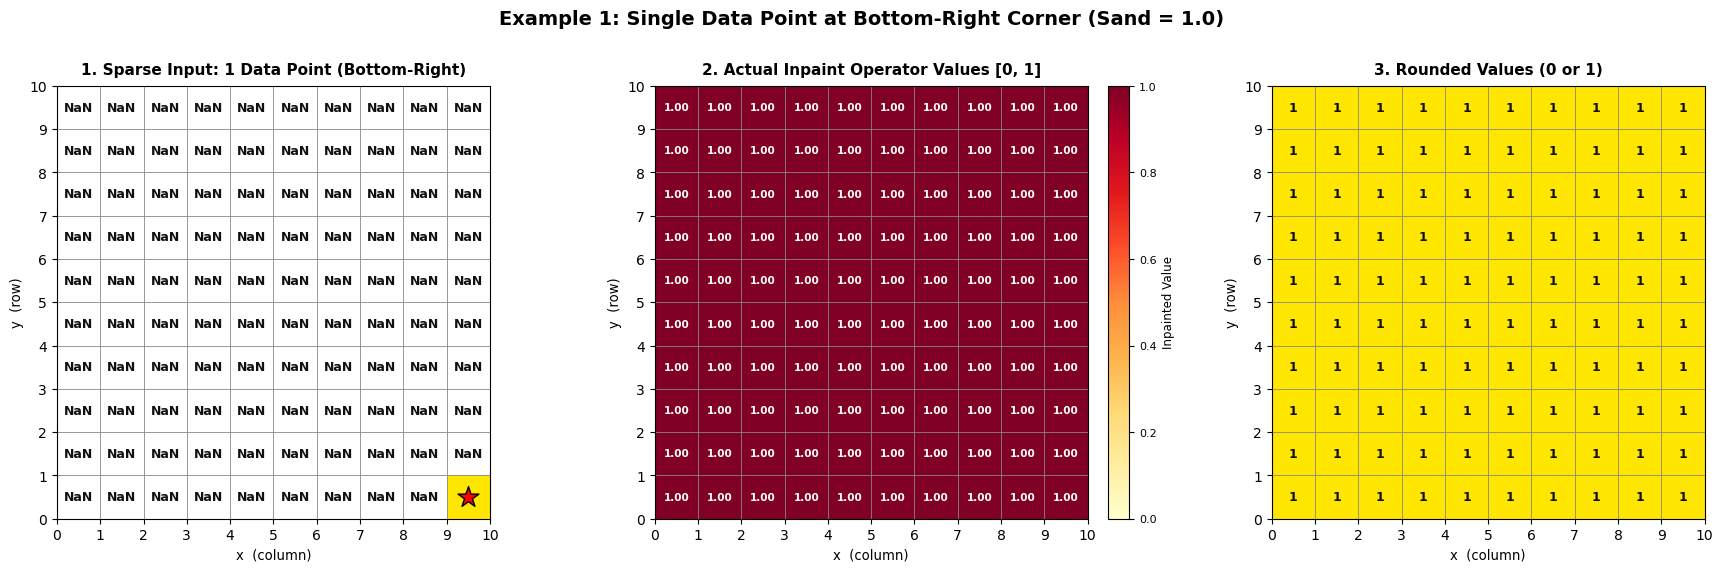

In [4]:
# -----------------------------------------------------------------------------
# Plot 3-panel figure for Example 1
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: Sparse Data
plot_binary_rounded(grid_ex1, "1. Sparse Input: 1 Data Point (Bottom-Right)", axes[0])
axes[0].scatter(9.5, 0.5, marker='*', s=250, c='red', edgecolors='black', zorder=5)

# Panel 2: Actual Biharmonic Values (Continuous)
plot_continuous_field(inpainted_ex1, "2. Actual Inpaint Operator Values [0, 1]", axes[1],
                      cmap='YlOrRd', vmin=0.0, vmax=1.0)

# Panel 3: Rounded Values (0 or 1)
plot_binary_rounded(rounded_ex1, "3. Rounded Values (0 or 1)", axes[2])

plt.suptitle("Example 1: Single Data Point at Bottom-Right Corner (Sand = 1.0)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 💡 Observation from Example 1:
- With only a **single boundary condition** ($u=1.0$ at the bottom-right corner) and natural zero-derivative boundary conditions at the domain edges, the biharmonic equation $\nabla^4 u = 0$ is solved by a **constant field**: $u(x, y) = 1.00$ everywhere.
- Every cell receives an inpaint value of exactly `1.00`.
- Rounding $1.00$ to the nearest integer yields `1` for every cell. Thus, a single data point fills the entire grid with its value.


## 2. Example 2: Effect of the Biharmonic Function with a Second Data Point (Top-Left)

Now we introduce a **second data point** at the opposite corner:
- **Bottom-Right Corner** `(row=0, col=9)` or `(x=9, y=0)`: Value = **$1.0$** (Sand present).
- **Top-Left Corner** `(row=9, col=0)` or `(x=0, y=9)`: Value = **$0.0$** (Sand absent / non-sand).
- The remaining **98 cells are unconstrained** (`NaN`).

This represents the exact binary sub-problem solved inside `one_vs_all`:
- How does the presence of Sand at one corner and its absence at another corner interpolate across space?
- What continuous values emerge between 0.0 and 1.0?
- What does the rounded decision surface look like?


In [5]:
# -----------------------------------------------------------------------------
# 2. Construct 10x10 sparse grid with 2 data points:
#    - Bottom-right (row=0, col=9): 1.0 (Sand)
#    - Top-left (row=9, col=0):     0.0 (Not Sand)
# -----------------------------------------------------------------------------
grid_ex2 = np.full((GRID_N, GRID_N), np.nan)
grid_ex2[0, 9] = 1.0  # Bottom-right = 1.0 (Sand)
grid_ex2[9, 0] = 0.0  # Top-left     = 0.0 (Not Sand)

# Inpainting mask: True for NaNs, False for known cells
mask_ex2 = np.isnan(grid_ex2)

# Set NaNs to 0 for inpainting algorithm
image_ex2_input = np.nan_to_num(grid_ex2, nan=0.0)

# Run biharmonic inpainting
inpainted_ex2 = inpaint_biharmonic(image_ex2_input, mask_ex2)

# Round to discrete 0 or 1 (threshold at 0.5)
rounded_ex2 = np.round(inpainted_ex2)

print("Example 2 — Inpainted continuous array (rounded to 2 decimals):")
print(np.round(inpainted_ex2, 2))
print(f"\nMin value: {inpainted_ex2.min():.2f}, Max value: {inpainted_ex2.max():.2f}")
print(f"Diagonal center value (row=4, col=5): {inpainted_ex2[4, 5]:.2f}")


Example 2 — Inpainted continuous array (rounded to 2 decimals):
[[0.5  0.52 0.56 0.61 0.67 0.75 0.82 0.9  0.96 1.  ]
 [0.48 0.5  0.54 0.59 0.65 0.72 0.8  0.87 0.92 0.96]
 [0.44 0.46 0.5  0.55 0.61 0.68 0.75 0.82 0.87 0.9 ]
 [0.39 0.41 0.45 0.5  0.56 0.63 0.69 0.75 0.8  0.82]
 [0.33 0.35 0.39 0.44 0.5  0.57 0.63 0.68 0.72 0.75]
 [0.25 0.28 0.32 0.37 0.43 0.5  0.56 0.61 0.65 0.67]
 [0.18 0.2  0.25 0.31 0.37 0.44 0.5  0.55 0.59 0.61]
 [0.1  0.13 0.18 0.25 0.32 0.39 0.45 0.5  0.54 0.56]
 [0.04 0.08 0.13 0.2  0.28 0.35 0.41 0.46 0.5  0.52]
 [0.   0.04 0.1  0.18 0.25 0.33 0.39 0.44 0.48 0.5 ]]

Min value: 0.00, Max value: 1.00
Diagonal center value (row=4, col=5): 0.57


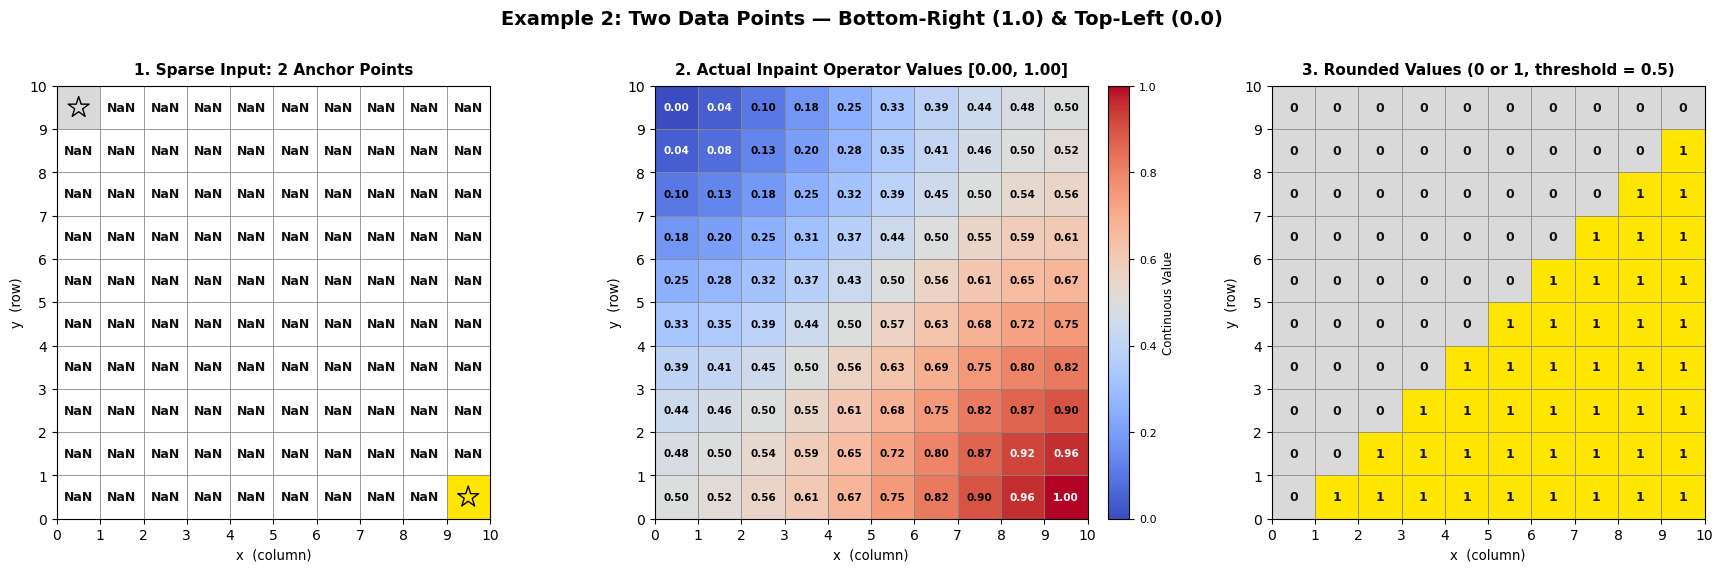

In [6]:
# -----------------------------------------------------------------------------
# Plot 3-panel figure for Example 2
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: Sparse Data with 2 Points
plot_binary_rounded(grid_ex2, "1. Sparse Input: 2 Anchor Points", axes[0])
axes[0].scatter([9.5, 0.5], [0.5, 9.5], marker='*', s=250, c=['#FFE600', '#D9D9D9'],
                edgecolors='black', zorder=5)

# Panel 2: Actual Biharmonic Values (Continuous Gradient)
plot_continuous_field(inpainted_ex2, "2. Actual Inpaint Operator Values [0.00, 1.00]", axes[1],
                      cmap='coolwarm', vmin=0.0, vmax=1.0, cbar_label='Continuous Value')

# Panel 3: Rounded Values (0 or 1)
plot_binary_rounded(rounded_ex2, "3. Rounded Values (0 or 1, threshold = 0.5)", axes[2])

plt.suptitle("Example 2: Two Data Points — Bottom-Right (1.0) & Top-Left (0.0)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 💡 Observations from Example 2:
1. **Smooth Harmonic/Biharmonic Transition**:
   - The inpaint operator smoothly bridges the gap between $0.00$ at top-left and $1.00$ at bottom-right.
   - Notice how the values along the perpendicular diagonal (from bottom-left to top-right) hover around **$0.50$** (the point of equal likelihood).
2. **Curvature Minimization**:
   - Notice how the values change smoothly across every row and column, without sharp kinks or discontinuities.
3. **Thresholding / Rounding**:
   - When rounded to $0$ or $1$, cells with value $< 0.50$ round to $0$ (grey), while cells $\ge 0.50$ round to $1$ (yellow).
   - This creates a **clean diagonal boundary** splitting the grid into two equal regions of influence!


## 3. Example 3: How One-vs-All Works with Two Geological Units (Sand & Clay)

Now we apply this to real geological classification:
- **Top-Left Corner** `(row=9, col=0)` has **Clay** (`Unit 2`, green).
- **Bottom-Right Corner** `(row=0, col=9)` has **Sand** (`Unit 5`, yellow).

---

### The One-vs-All (OvA) Algorithm Step-by-Step:

1. **Identify Unique Geological Units**: Here, $\mathcal{U} = \{\text{Clay } (2), \text{Sand } (5)\}$.
2. **Decompose into Binary Indicators**:
   - For **Clay (2)**: Clay cell is $1.0$, Sand cell is $0.0$, empty cells are `NaN`.
   - For **Sand (5)**: Sand cell is $1.0$, Clay cell is $0.0$, empty cells are `NaN`.
3. **Inpaint Each Indicator Separately**:
   - Solve $\nabla^4 P_{\text{raw}}(\text{Clay}) = 0 \implies$ continuous Clay field.
   - Solve $\nabla^4 P_{\text{raw}}(\text{Sand}) = 0 \implies$ continuous Sand field.
4. **Normalize across classes**:
   $$P_{\text{norm}}(c) = \frac{P_{\text{raw}}(c)}{\sum_{k} P_{\text{raw}}(k)}$$
5. **Classify by Maximum Probability (Argmax)**:
   $$\text{Unit}(x, y) = \arg\max_{c \in \mathcal{U}} P_{\text{norm}}(c)$$
6. **Quantify Uncertainty**:
   $$\text{Uncertainty}(x, y) = 100 \times \left(1 - \max_c P_{\text{norm}}(c)\right) \%$$


In [7]:
# -----------------------------------------------------------------------------
# Step 1: Define the sparse geological grid
# -----------------------------------------------------------------------------
geo_sparse = np.full((GRID_N, GRID_N), np.nan)
geo_sparse[9, 0] = 2.0  # Top-left = Clay (2)
geo_sparse[0, 9] = 5.0  # Bottom-right = Sand (5)

# Known cells mask (False for known data points, True for cells to inpaint)
known_mask = np.isnan(geo_sparse)

# -----------------------------------------------------------------------------
# Step 2: Formulate binary indicator grids for each unit
# -----------------------------------------------------------------------------
# Problem A: Clay (2) vs All
# - At Clay location (9, 0): value = 1.0
# - At Sand location (0, 9): value = 0.0 (it is NOT clay)
clay_binary = np.where(geo_sparse == 2.0, 1.0, 0.0)
P_clay_raw = inpaint_biharmonic(clay_binary, known_mask)

# Problem B: Sand (5) vs All
# - At Sand location (0, 9): value = 1.0
# - At Clay location (9, 0): value = 0.0 (it is NOT sand)
sand_binary = np.where(geo_sparse == 5.0, 1.0, 0.0)
P_sand_raw = inpaint_biharmonic(sand_binary, known_mask)

# -----------------------------------------------------------------------------
# Step 3: Normalization
# -----------------------------------------------------------------------------
sum_P = P_clay_raw + P_sand_raw
P_clay_norm = P_clay_raw / sum_P
P_sand_norm = P_sand_raw / sum_P

# -----------------------------------------------------------------------------
# Step 4: Combine via argmax to determine predicted unit
# -----------------------------------------------------------------------------
# If P(Sand) >= P(Clay), assign Sand (5), else Clay (2)
predicted_units = np.where(P_sand_norm >= P_clay_norm, 5.0, 2.0)

# Uncertainty in percent (peaks at 50% where probabilities are equal)
uncertainty_perc = 100.0 * (1.0 - np.maximum(P_clay_norm, P_sand_norm))

print("One-vs-All manual calculation complete.")
print(f"Clay probability range : [{P_clay_norm.min():.2f}, {P_clay_norm.max():.2f}]")
print(f"Sand probability range : [{P_sand_norm.min():.2f}, {P_sand_norm.max():.2f}]")
print(f"Uncertainty range (%)  : [{uncertainty_perc.min():.1f}%, {uncertainty_perc.max():.1f}%]")


One-vs-All manual calculation complete.
Clay probability range : [0.00, 1.00]
Sand probability range : [0.00, 1.00]
Uncertainty range (%)  : [0.0%, 50.0%]


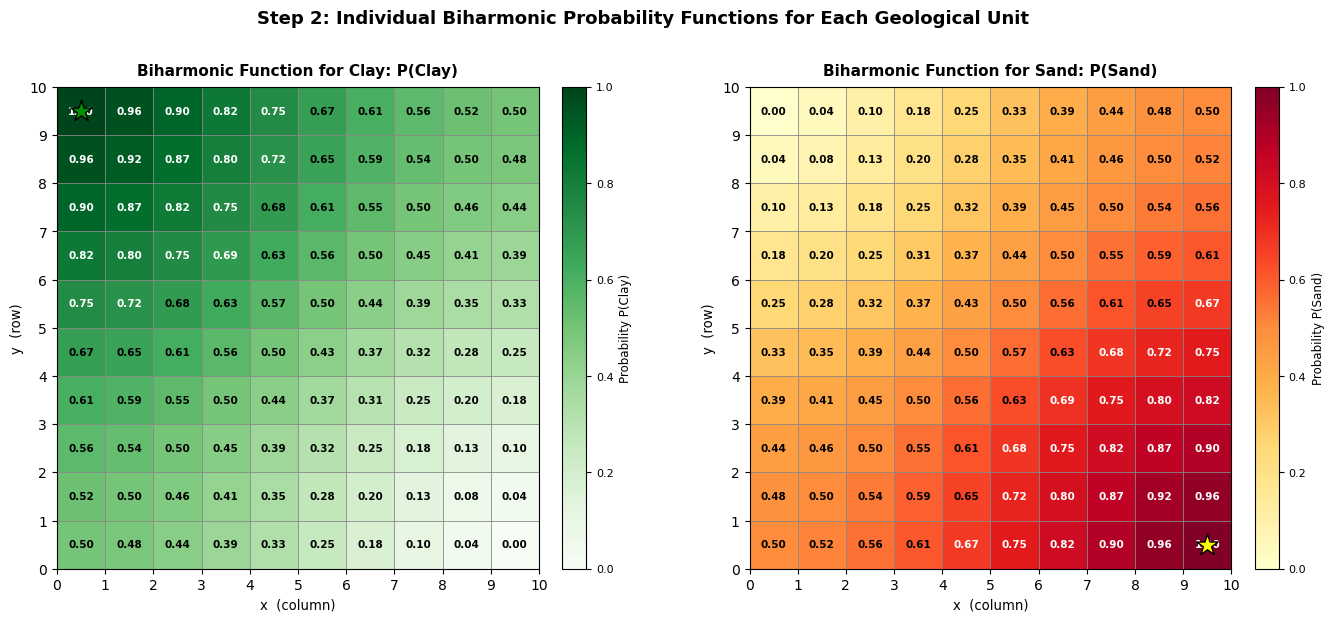

In [8]:
# -----------------------------------------------------------------------------
# Visualise the two individual biharmonic functions side-by-side
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_continuous_field(P_clay_norm, "Biharmonic Function for Clay: P(Clay)", axes[0],
                      cmap='Greens', vmin=0.0, vmax=1.0, cbar_label="Probability P(Clay)")
axes[0].scatter(0.5, 9.5, marker='*', s=260, c='#009200', edgecolors='black', zorder=5)

plot_continuous_field(P_sand_norm, "Biharmonic Function for Sand: P(Sand)", axes[1],
                      cmap='YlOrRd', vmin=0.0, vmax=1.0, cbar_label="Probability P(Sand)")
axes[1].scatter(9.5, 0.5, marker='*', s=260, c='#FFFF00', edgecolors='black', zorder=5)

plt.suptitle("Step 2: Individual Biharmonic Probability Functions for Each Geological Unit",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


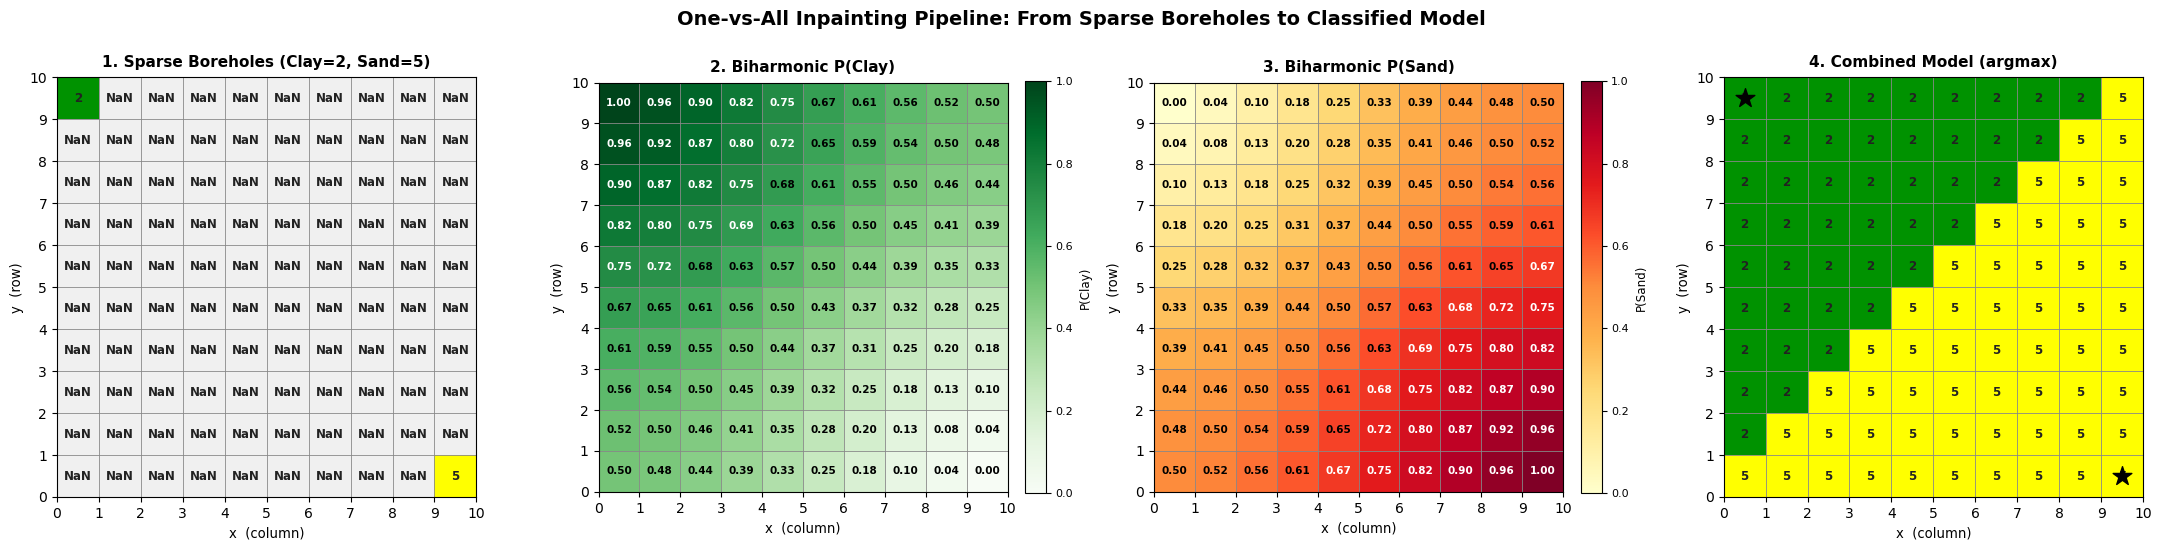

In [9]:
# -----------------------------------------------------------------------------
# Comprehensive 4-panel figure showing the complete One-vs-All pipeline
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 5.2))

# 1. Sparse Input
plot_grid(geo_sparse, "1. Sparse Boreholes (Clay=2, Sand=5)", axes[0])

# 2. Biharmonic Clay Function
plot_continuous_field(P_clay_norm, "2. Biharmonic P(Clay)", axes[1],
                      cmap='Greens', vmin=0.0, vmax=1.0, cbar_label="P(Clay)")

# 3. Biharmonic Sand Function
plot_continuous_field(P_sand_norm, "3. Biharmonic P(Sand)", axes[2],
                      cmap='YlOrRd', vmin=0.0, vmax=1.0, cbar_label="P(Sand)")

# 4. Final Combined Model (argmax)
plot_grid(predicted_units, "4. Combined Model (argmax)", axes[3])
axes[3].scatter([0.5, 9.5], [9.5, 0.5], marker='*', s=200, c='black', zorder=5)

plt.suptitle("One-vs-All Inpainting Pipeline: From Sparse Boreholes to Classified Model",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


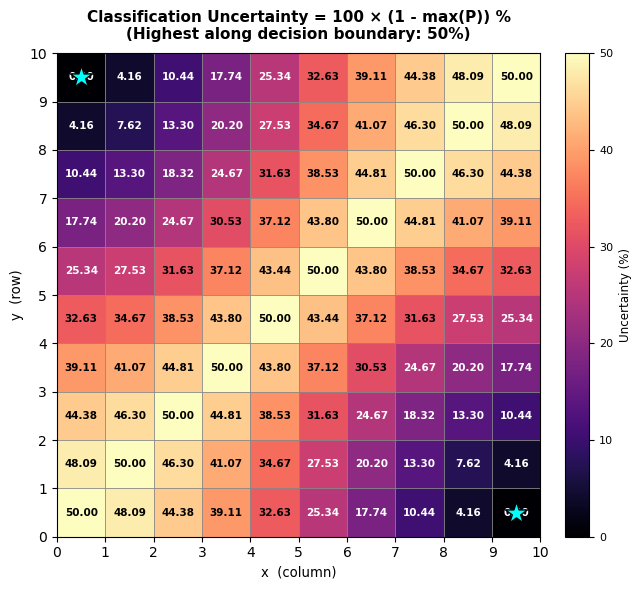

In [10]:
# -----------------------------------------------------------------------------
# Plot Uncertainty Map
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

plot_continuous_field(uncertainty_perc, "Classification Uncertainty Map (%)", ax,
                      cmap='magma', vmin=0.0, vmax=50.0, cbar_label="Uncertainty (%)")

# Highlight the two anchor boreholes
ax.scatter([0.5, 9.5], [9.5, 0.5], marker='*', s=280, c='cyan', edgecolors='black',
           zorder=5)

plt.title("Classification Uncertainty = 100 × (1 - max(P)) %\n(Highest along decision boundary: 50%)",
          fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


In [11]:
# -----------------------------------------------------------------------------
# Verify that Geo_Gridder.one_vs_all() produces the exact same result
# -----------------------------------------------------------------------------
training_pts = np.array([
    [0.0, 9.0],  # Clay at x=0, y=9 (top-left)
    [9.0, 0.0],  # Sand at x=9, y=0 (bottom-right)
])
training_data = np.array([2.0, 5.0])

gg = Geo_Gridder(
    training_points = training_pts,
    training_data   = training_data,
    method          = 'mode'
)

# Build 10x10 regular grid
gg.make_grid(xmin=0, xmax=GRID_N - 1, ymin=0, ymax=GRID_N - 1, pts=(GRID_N, GRID_N))
gg.gridder()

# Run library one_vs_all with isotropic weights (x_weight=1.0, y_weight=1.0)
result_gg = gg.one_vs_all(x_weight=1.0, y_weight=1.0)

# Check exact equality
matches = np.array_equal(gg.prediction_data, predicted_units)
print(f"Geo_Gridder.one_vs_all() output matches manual derivation exactly: {matches}")
print(f"Unique units in Geo_Gridder model: {np.unique(gg.prediction_data).tolist()}")


Geo_Gridder.one_vs_all() output matches manual derivation exactly: True
Unique units in Geo_Gridder model: [2.0, 5.0]


## 4. Why One-vs-All is Essential: Failure of Direct Integer Inpainting

To understand why the **One-vs-All** algorithm is necessary, let's see what happens if someone attempts to inpaint the raw geological unit numbers directly:
- Top-left is **Clay (`2`)**
- Bottom-right is **Sand (`5`)**

If we pass `[2, 5]` directly to the continuous biharmonic solver:
1. The solver treats $2$ and $5$ as continuous physical quantities (like temperature or elevation).
2. It interpolates smooth intermediate values: $2.3, 2.7, 3.1, 3.5, 4.0, 4.6...$
3. When rounded to nearest integers, it creates:
   - **Unit 3 (`Silt`)**
   - **Unit 4 (`Nothing`)**
4. Neither Silt nor Nothing was ever observed in the boreholes! Direct inpainting **hallucinates non-existent geological units**.

---
Let's see this in action:


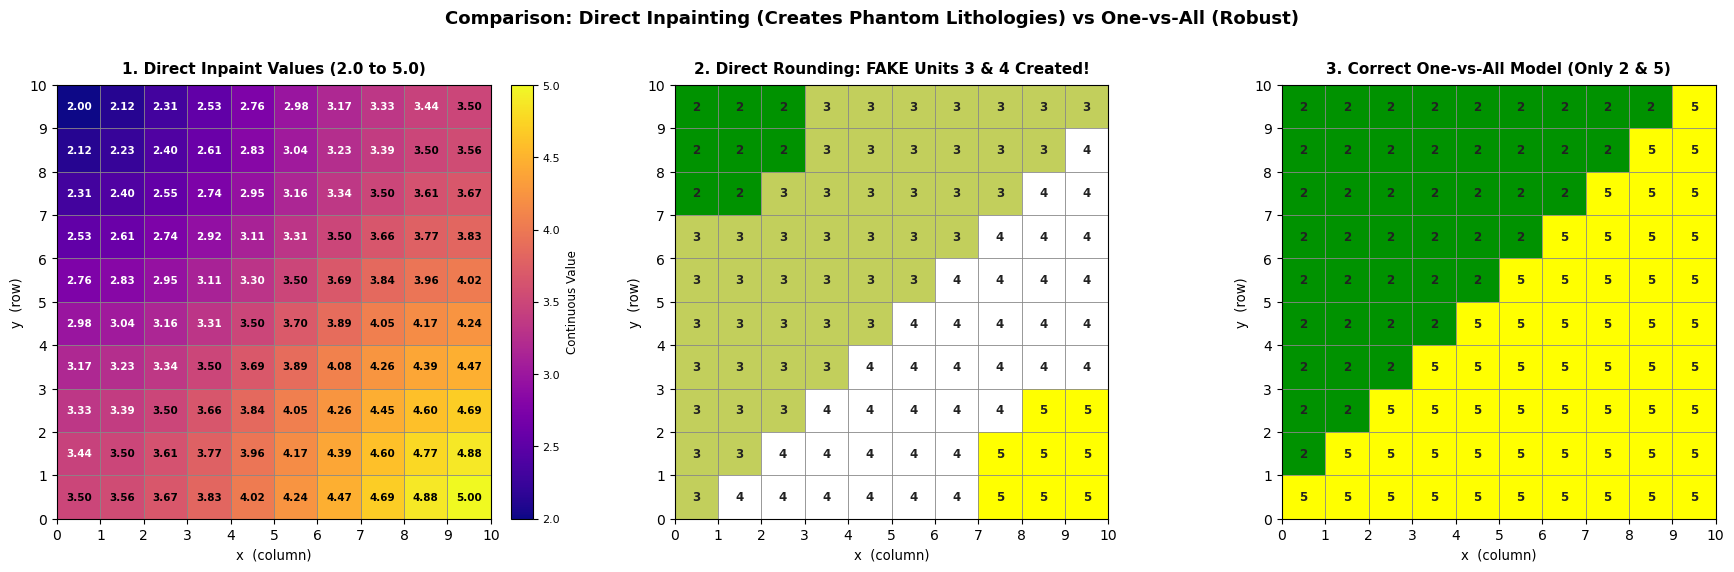

Direct inpainting rounded unique units: [2.0, 3.0, 4.0, 5.0]
Notice how Units 3 (Silt) and 4 (Nothing) appear despite never being present in the input!


In [12]:
# -----------------------------------------------------------------------------
# Direct inpainting on integer labels (2 and 5) WITHOUT One-vs-All
# -----------------------------------------------------------------------------
raw_direct = np.full((GRID_N, GRID_N), np.nan)
raw_direct[9, 0] = 2.0  # Clay (2)
raw_direct[0, 9] = 5.0  # Sand (5)

mask_direct = np.isnan(raw_direct)
inpaint_direct = inpaint_biharmonic(np.nan_to_num(raw_direct, nan=0.0), mask_direct)
rounded_direct = np.round(inpaint_direct)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

plot_continuous_field(inpaint_direct, "1. Direct Inpaint Values (2.0 to 5.0)", axes[0],
                      cmap='plasma', vmin=2.0, vmax=5.0, cbar_label="Continuous Value")

plot_grid(rounded_direct, "2. Direct Rounding: FAKE Units 3 & 4 Created!", axes[1])

plot_grid(predicted_units, "3. Correct One-vs-All Model (Only 2 & 5)", axes[2])

plt.suptitle("Comparison: Direct Inpainting (Creates Phantom Lithologies) vs One-vs-All (Robust)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Direct inpainting rounded unique units:", np.unique(rounded_direct).tolist())
print("Notice how Units 3 (Silt) and 4 (Nothing) appear despite never being present in the input!")


## 5. Summary & Key Takeaways

| Feature | Direct Integer Inpainting | One-vs-All (`one_vs_all`) |
| :--- | :--- | :--- |
| **Input Data** | Integer labels directly in a single grid | One binary indicator grid per unique geological unit |
| **Inpaint Space** | Continuous label values ($2.0 \to 5.0$) | Bounded probabilities ($0.0 \to 1.0$) per unit |
| **Classification** | Rounding continuous numbers | Probabilistic maximum ($\arg\max$) across class fields |
| **Risk of Phantom Units** | ⚠️ **High**: interpolates fake intermediate units ($3, 4$) | ✅ **Zero**: only observed units can ever be predicted |
| **Uncertainty Output** | None | ✅ Exact spatial uncertainty map ($100 - 100 \times \max(P)$) |
| **Anisotropic Weights** | N/A | ✅ Supports preferential directional weights (`x_weight`, `y_weight`) |

This demonstrates why **One-vs-All biharmonic inpainting** is the correct mathematical foundation for geological surface and subsurface modeling.
